In [ ]:
# Lab 2: Classification Using KNN and RNN Algorithms

Name: Sireesha Pudi

Course: Advanced Big Data and Data Mining (MSCS-634)

Lab Assignment: Lab 2

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import RadiusNeighborsClassifier
from sklearn.metrics import accuracy_score

print("Libraries loaded successfully")

Libraries loaded successfully


In [6]:
wine = load_wine()

wine_df = pd.DataFrame(
    wine.data,
    columns=wine.feature_names
)

wine_df["Target"] = wine.target

wine_df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,Target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [7]:
wine_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  Target          

In [8]:
wine_df["Target"].value_counts()

Target
1    71
0    59
2    48
Name: count, dtype: int64

In [ ]:
The class distribution shows the number of wine samples available in each target category. Understanding class balance helps evaluate whether the dataset contains a relatively equal representation of each wine class.

In [9]:
X = wine.data
y = wine.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Set Size:", X_train.shape)
print("Testing Set Size:", X_test.shape)

Training Set Size: (142, 13)
Testing Set Size: (36, 13)


In [10]:
knn_values = [1, 5, 11, 15, 21]

knn_accuracy_scores = []

for k in knn_values:

    knn_model = KNeighborsClassifier(
        n_neighbors=k
    )

    knn_model.fit(
        X_train,
        y_train
    )

    predictions = knn_model.predict(
        X_test
    )

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    knn_accuracy_scores.append(
        accuracy
    )

    print(
        "k =", k,
        "Accuracy =", round(accuracy, 4)
    )

k = 1 Accuracy = 0.7778
k = 5 Accuracy = 0.7222
k = 11 Accuracy = 0.75
k = 15 Accuracy = 0.75
k = 21 Accuracy = 0.7778


In [ ]:
KNN classifies new observations by examining nearby training samples. Different values of k were tested to determine how neighborhood size influences classification accuracy.

In [11]:
radius_values = [
    350,
    400,
    450,
    500,
    550,
    600
]

rnn_accuracy_scores = []

for radius in radius_values:

    rnn_model = RadiusNeighborsClassifier(
        radius=radius,
        outlier_label='most_frequent'
    )

    rnn_model.fit(
        X_train,
        y_train
    )

    predictions = rnn_model.predict(
        X_test
    )

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    rnn_accuracy_scores.append(
        accuracy
    )

    print(
        "Radius =", radius,
        "Accuracy =", round(accuracy, 4)
    )

Radius = 350 Accuracy = 0.75
Radius = 400 Accuracy = 0.7222
Radius = 450 Accuracy = 0.7222
Radius = 500 Accuracy = 0.7222
Radius = 550 Accuracy = 0.7222
Radius = 600 Accuracy = 0.7222


In [ ]:
Radius Neighbors classification uses all observations located within a specified distance threshold. Different radius values were evaluated to observe how expanding the neighborhood influences model performance.

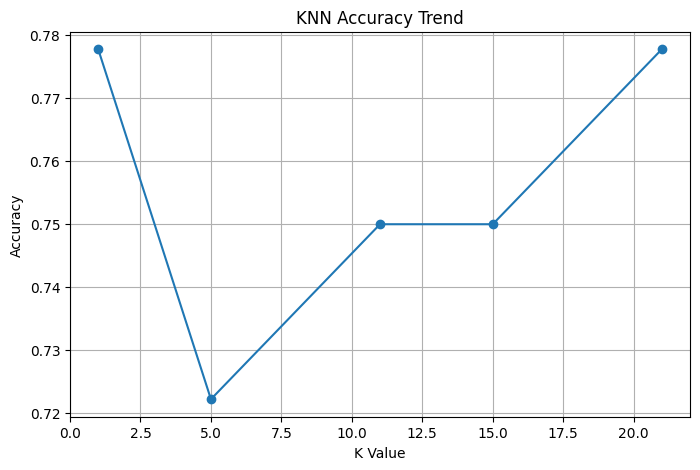

In [12]:
plt.figure(figsize=(8,5))

plt.plot(
    knn_values,
    knn_accuracy_scores,
    marker="o"
)

plt.title("KNN Accuracy Trend")
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.grid(True)

plt.show()

In [ ]:
The KNN accuracy trend demonstrates how model performance changes when different numbers of neighbors are considered. Smaller values may capture local patterns while larger values provide smoother decision boundaries.

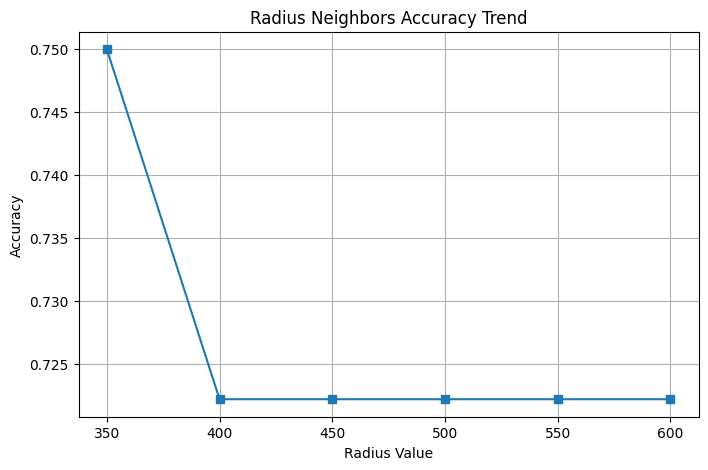

In [13]:
plt.figure(figsize=(8,5))

plt.plot(
    radius_values,
    rnn_accuracy_scores,
    marker="s"
)

plt.title("Radius Neighbors Accuracy Trend")
plt.xlabel("Radius Value")
plt.ylabel("Accuracy")
plt.grid(True)

plt.show()

In [ ]:
The Radius Neighbors trend illustrates how classification accuracy responds to increasing neighborhood radius values. Very large radius values may include additional observations that can influence predictions.

In [14]:
comparison_df = pd.DataFrame({
    "K Value": knn_values,
    "KNN Accuracy": knn_accuracy_scores
})

comparison_df

,K Value,KNN Accuracy
0,1,0.777778
1,5,0.722222
2,11,0.750000
3,15,0.750000
4,21,0.777778


In [ ]:
## Comparison of KNN and Radius Neighbors Classifiers

Both classification techniques were successfully applied to the Wine dataset. KNN relies on a fixed number of neighboring observations while Radius Neighbors uses a distance threshold to determine neighboring samples.

Based on the observed results, KNN provided stable classification performance across multiple values of k. Radius Neighbors also produced strong results but its performance depended heavily on the chosen radius value.

KNN is generally more appropriate when data density remains relatively consistent throughout the dataset. Radius Neighbors may be beneficial when sample density varies because the number of neighbors adjusts automatically according to the selected radius.

The experiment demonstrates the importance of parameter tuning when building classification models. Small changes in parameter values can significantly influence predictive performance.